In [3]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [1]:
#explode job_skills and plot top skills needed for data analyst and data scientist.

df_exploded = df.explode('job_skills')

NameError: name 'df' is not defined

In [67]:
#groupby to count skills per job title
df_exploded = df_exploded.groupby(['job_title_short', 'job_skills']).size()



In [68]:
#convert this hiearchical data into normal 2d data
df_exploded = df_exploded.reset_index(name='skill_count')
#sort values by skill_count for plotting purposes
df_exploded = df_exploded.sort_values(by='skill_count', ascending=False)
df_exploded

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


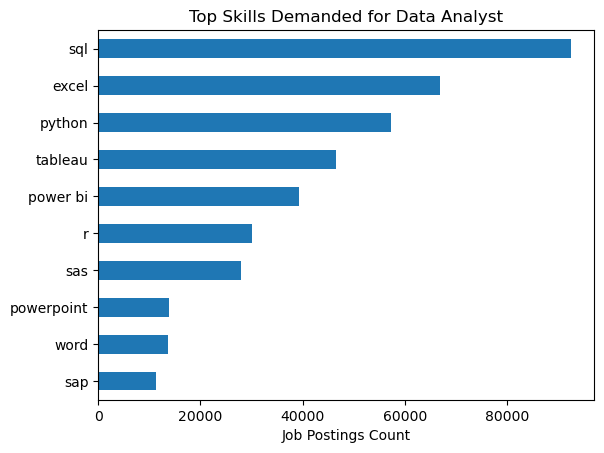

In [97]:
#Demanded skills for data analyst
df_data_analyst = df_exploded[df_exploded['job_title_short'] == 'Data Analyst']
df_data_analyst.head(10).plot(x='job_skills', y='skill_count', kind='barh')
plt.gca().invert_yaxis()
plt.title('Top Skills Demanded for Data Analyst')
plt.ylabel('')
plt.xlabel('Job Postings Count')
plt.legend().set_visible(False)
plt.show()

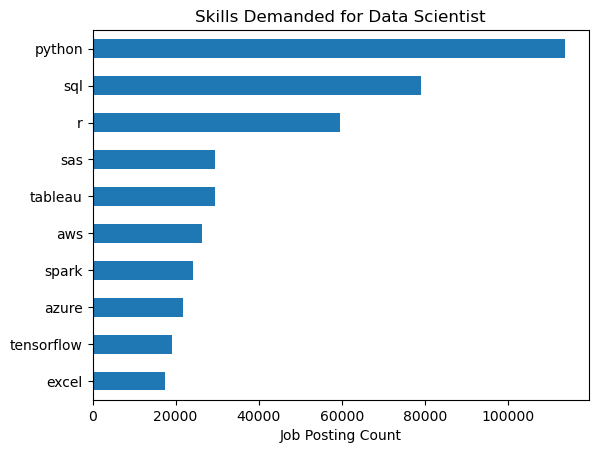

In [ ]:
#Plotting skills demanded for data scientists
df_data_scientist = df_exploded[df_exploded['job_title_short'] == 'Data Scientist']
df_data_scientist.head(10).plot(x='job_skills', y='skill_count', kind='barh')
plt.gca().invert_yaxis()
plt.title('Skills Demanded for Data Scientist')
plt.ylabel('')
plt.xlabel('Job Posting Count')
plt.legend().set_visible(False)
plt.show()